Introduction: This research is based on a personal interest in looking at the comorbidity of Attention Deficit Hyperactivity Disorder (ADHD), anxiety, and depression. To narrow the scope of the project, a data set available through the CDC will be used. This data set consists of a sample size of 3,018 children between 2-15 years old in 2011-2012 whose parents or guardians reported a prior diagnosis of ADHD or Tourette’s syndrome by a healthcare provider and who were still under 18 during a later re-interview. 

 

Research Question: What are the most prominent comorbidities of ADHD in this data set?  

Data Source: Data provided by the CDC archive looking at the National Survey of the Diagnosis and Treatment of ADHD and Tourette Syndrome (NS-DATA). This project was sponsored by the National Center on Birth Defects and Developmental Disabilities (NCBDDD) and the National Center for Health Statistics. Data was last reviewed on February 15, 2022. 

 

Final Deliverable: The final deliverable will consist of a Github link provided via Canvas. The Github link will include all project files including README file, a requirements.txt file, a python script for extracting the dataset, and a Jupyter notebook with data visualization. 

Importing modules for analysis

In [2]:
import pyreadstat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Accessing Dataset

In [3]:
sas_path = "nsdata_adhd_puf_u.sas7bdat"
df, meta = pyreadstat.read_sas7bdat("nsdata_adhd_puf_u.sas7bdat")

In [14]:
# Display basic info about the dataframe
print("Shape (rows, columns):", df.shape)
print(f"\nFirst few rows:\n{df.head()}")


# print column names with their labels
col_info = pd.DataFrame(
    {
        "Variable Name": meta.column_names,
        "Variable Label": [
            meta.column_names_to_labels.get(c, "") for c in meta.column_names
        ],
    }
)
print(col_info)

Shape (rows, columns): (2966, 267)

First few rows:
   IDNUMR  STATE  SAMPLE  SEX  HISPANIC  RACER  AGE_NSDATAR  ADHD_A1_AGE_STD  \
0    38.0    8.0     1.0  2.0       0.0    1.0          3.0              6.0   
1    56.0   27.0     1.0  1.0       1.0    1.0          6.0              4.0   
2    91.0   24.0     1.0  1.0       0.0    1.0          4.0              9.0   
3   201.0   30.0     1.0  1.0       0.0    1.0          6.0             11.0   
4   236.0   24.0     1.0  1.0       0.0    1.0          5.0             10.0   

   ADHD_A1_1_NEW  ADHD_A1_2  ...  ADHD_G1_4  ADHD_G1_5  ADHD_G1_6  ADHD_G1_7  \
0           10.0        1.0  ...        1.0        0.0        0.0        NaN   
1            9.0        1.0  ...        6.0        0.0        0.0        0.0   
2           10.0        1.0  ...        0.0        0.0        0.0        NaN   
3            6.0        1.0  ...        0.0        0.0        0.0        0.0   
4            6.0        1.0  ...        1.0        0.0        0.0  

In [5]:
# Search for multiple keywords
search_keywords = ["anxiety", "depression", "antidepressant", "anxiolytic"]

matching_vars = []
for var in meta.column_names:
    label = meta.column_names_to_labels.get(var, "")
    if any(keyword.lower() in label.lower() for keyword in search_keywords):
        matching_vars.append((var, label))

# pd.set_option("display.max_colwidth", None)
print(f"\nVariables containing any of {search_keywords}:")
search_results = pd.DataFrame(
    matching_vars, columns=["Variable Name", "Variable Label"]
)
print(df[search_results["Variable Name"]].count())


Variables containing any of ['anxiety', 'depression', 'antidepressant', 'anxiolytic']:
ADHD_A4_1CA_X03       130
ADHD_A4_1CA_X04       130
ADHD_B1_1_10         2966
ADHD_B1_1_13         2966
ADHD_B1_2_10          629
ADHD_B1_2_13          558
ADHD_MEDS_CLASS_2    1752
ADHD_MEDS_CLASS_6    1752
dtype: int64


In [ ]:
# Step 1: Search for all possible comorbidities beyond anxiety and depression
comorbidity_keywords = {
    "anxiety": ["anxiety", "anxious", "anxiolytic"],
    "depression": ["depression", "antidepressant", "depressive"],
    "behavior": ["behavior", "behavioral", "conduct", "oppositional"],
    "learning": ["learning", "dyslexia", "reading"],
    "sleep": ["sleep", "insomnia", "sleep disorder"],
    "asthma": ["asthma"],
    "allergy": ["allergy", "allergic"],
    "headache": ["headache", "migraine"],
    "speech": ["speech", "language"],
    "tic": ["tic", "tourette"],
    "autism": ["autism", "autistic", "spectrum"],
}

# Identify variables for each comorbidity category
comorbidity_vars = {}
for condition, keywords in comorbidity_keywords.items():
    condition_vars = []
    for var in meta.column_names:
        label = meta.column_names_to_labels.get(var, "")
        if any(keyword.lower() in label.lower() for keyword in keywords):
            condition_vars.append((var, label))
    if condition_vars:
        comorbidity_vars[condition] = condition_vars

# Step 2: Calculate prevalence of each comorbidity
print("=" * 80)
print("COMORBIDITY PREVALENCE ANALYSIS")
print("=" * 80)

comorbidity_summary = []

for condition, vars_list in comorbidity_vars.items():
    print(f"\n{condition.upper()}:")
    for var, label in vars_list:
        # Get value counts
        value_counts = df[var].value_counts()
        total_responses = df[var].count()
        
        # Print details
        print(f"  {var}: {label}")
        print(f"    Total responses: {total_responses}")
        print(f"    Value counts:\n{df[var].value_counts().to_string()}\n")
        
        # Store summary
        for value, count in value_counts.items():
            percentage = (count / total_responses) * 100 if total_responses > 0 else 0
            comorbidity_summary.append({
                'Condition': condition,
                'Variable': var,
                'Value': value,
                'Count': count,
                'Percentage': percentage,
                'Total_Responses': total_responses
            })

# Step 3: Create summary dataframe sorted by prevalence
summary_df = pd.DataFrame(comorbidity_summary)


COMORBIDITY PREVALENCE ANALYSIS

ANXIETY:
  ADHD_A4_1CA_X03: What was the diagnosis changed to? - Anxiety (NORC back coded)
    Total responses: 130
    Value counts:
ADHD_A4_1CA_X03
0.0    64
5.0    35
1.0    25
6.0     6

  ADHD_B1_1_10: Has a doctor or health care provider ever told you that [S.C.] had another anxiety disorder, such as generalized anxiety disorder, panic disorder, or a phobia?
    Total responses: 2966
    Value counts:
ADHD_B1_1_10
0.0    2324
1.0     629
6.0      13

  ADHD_B1_2_10: Does [S.C.] currently have another anxiety disorder, such as generalized anxiety disorder, panic disorder, or a phobia?
    Total responses: 629
    Value counts:
ADHD_B1_2_10
1.0    483
0.0    138
6.0      8

  ADHD_MEDS_CLASS_6: DERIVED. [S.C.] currently takes an anxiolytic for ADHD
    Total responses: 1752
    Value counts:
ADHD_MEDS_CLASS_6
0.0    1746
1.0       6


DEPRESSION:
  ADHD_A4_1CA_X04: What was the diagnosis changed to? - Depression (NORC back coded)
    Total responses

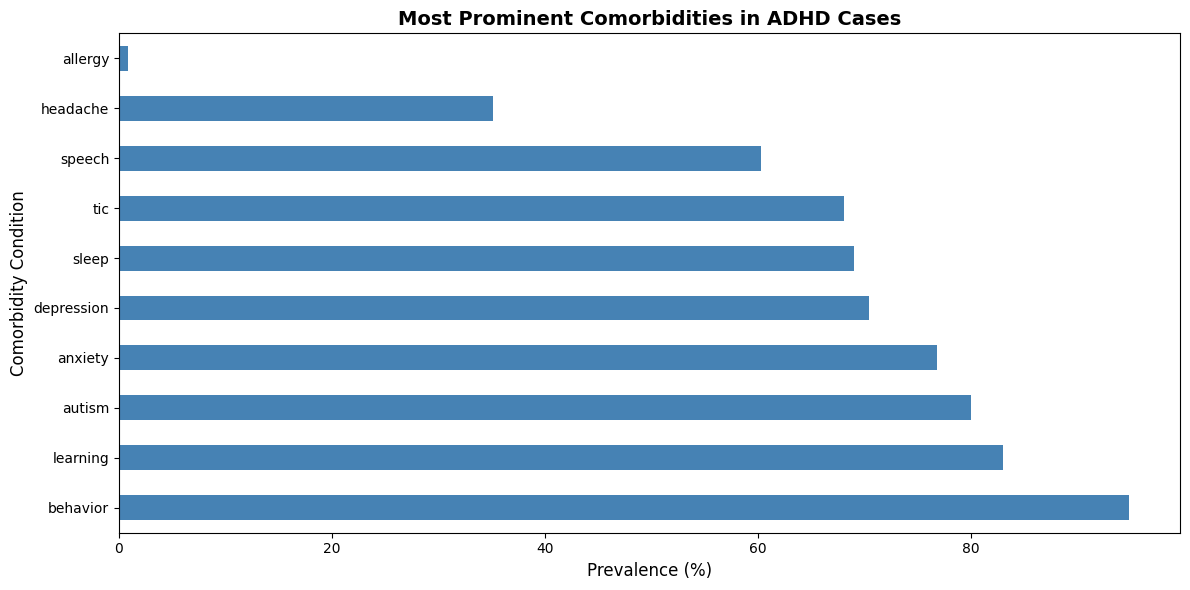

In [24]:
# ============================================================
# IDENTIFYING THE MOST PROMINENT COMORBIDITIES OF ADHD
# ============================================================

# Step 1: Search for all possible comorbidities beyond anxiety and depression
comorbidity_keywords = {
    "anxiety": ["anxiety", "anxious", "anxiolytic"],
    "depression": ["depression", "antidepressant", "depressive"],
    "behavior": ["behavior", "behavioral", "conduct", "oppositional"],
    "learning": ["learning", "dyslexia", "reading"],
    "sleep": ["sleep", "insomnia", "sleep disorder"],
    "asthma": ["asthma"],
    "allergy": ["allergy", "allergic"],
    "headache": ["headache", "migraine"],
    "speech": ["speech", "language"],
    "tic": ["tic", "tourette"],
    "autism": ["autism", "autistic", "spectrum"],
}

# Identify variables for each comorbidity category
comorbidity_vars = {}
for condition, keywords in comorbidity_keywords.items():
    condition_vars = []
    for var in meta.column_names:
        label = meta.column_names_to_labels.get(var, "")
        if any(keyword.lower() in label.lower() for keyword in keywords):
            condition_vars.append((var, label))
    if condition_vars:
        comorbidity_vars[condition] = condition_vars

# Step 2: Calculate prevalence of each comorbidity
print("=" * 80)
print("COMORBIDITY PREVALENCE ANALYSIS")
print("=" * 80)

comorbidity_summary = []

for condition, vars_list in comorbidity_vars.items():
    print(f"\n{condition.upper()}:")
    for var, label in vars_list:
        # Get value counts
        value_counts = df[var].value_counts()
        total_responses = df[var].count()
        
        # Print details
        print(f"  {var}: {label}")
        print(f"    Total responses: {total_responses}")
        print(f"    Value counts:\n{df[var].value_counts().to_string()}\n")
        
        # Store summary
        for value, count in value_counts.items():
            percentage = (count / total_responses) * 100 if total_responses > 0 else 0
            comorbidity_summary.append({
                'Condition': condition,
                'Variable': var,
                'Value': value,
                'Count': count,
                'Percentage': percentage,
                'Total_Responses': total_responses
            })

# Step 3: Create summary dataframe sorted by prevalence
summary_df = pd.DataFrame(comorbidity_summary)

# Filter for positive/affirmative responses (typically coded as 1 or "Yes")
positive_conditions = summary_df[
    (summary_df['Value'].astype(str).str.lower().isin(['1', 'yes', 'true'])) |
    (summary_df['Value'] == 1)
]

positive_conditions_sorted = positive_conditions.sort_values('Percentage', ascending=False)

print("\n" + "=" * 80)
print("TOP COMORBIDITIES BY PREVALENCE (Affirmative Responses)")
print("=" * 80)
print(positive_conditions_sorted[['Condition', 'Percentage', 'Count', 'Total_Responses']].to_string(index=False))

# Step 4: Visualize the top comorbidities
top_conditions = positive_conditions_sorted.groupby('Condition')['Percentage'].max().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
top_conditions.plot(kind='barh', color='steelblue')
plt.xlabel('Prevalence (%)', fontsize=12)
plt.ylabel('Comorbidity Condition', fontsize=12)
plt.title('Most Prominent Comorbidities in ADHD Cases', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Display found variables
print("\nANXIETY-RELATED VARIABLES:")
if anxiety_vars:
    anxiety_df = pd.DataFrame(anxiety_vars, columns=["Variable Name", "Variable Label"])
    print(anxiety_df.to_string(index=False))
else:
    print("No anxiety variables found")

print("\nDEPRESSION-RELATED VARIABLES:")
if depression_vars:
    depression_df = pd.DataFrame(
        depression_vars, columns=["Variable Name", "Variable Label"]
    )
    print(depression_df.to_string(index=False))
else:
    print("No depression variables found")

# Count occurrences of anxiety
if anxiety_vars:
    print("\nANXIETY CASE COUNTS")
    for var, label in anxiety_vars:
        print(f"\n{var}:")
        print(f"Label: {label}")
        print(f"Total non-null: {df[var].count()}")
        print("Value Counts:")
        print(df[var].value_counts())



ANXIETY-RELATED VARIABLES:
    Variable Name                                                                                                                                                  Variable Label
  ADHD_A4_1CA_X03                                                                                                  What was the diagnosis changed to? - Anxiety (NORC back coded)
     ADHD_B1_1_10 Has a doctor or health care provider ever told you that [S.C.] had another anxiety disorder, such as generalized anxiety disorder, panic disorder, or a phobia?
     ADHD_B1_2_10                                         Does [S.C.] currently have another anxiety disorder, such as generalized anxiety disorder, panic disorder, or a phobia?
ADHD_MEDS_CLASS_6                                                                                                          DERIVED. [S.C.] currently takes an anxiolytic for ADHD

DEPRESSION-RELATED VARIABLES:
    Variable Name                                  

In [10]:
# Display counts as a formatted table for anxiety
anxiety_keywords = ["anxiety", "anxious", "anxiolytic"]
anxiety_vars = []
for var in meta.column_names:
    label = meta.column_names_to_labels.get(var, "")
    if any(keyword.lower() in label.lower() for keyword in anxiety_keywords):
        anxiety_vars.append((var, label))
if anxiety_vars:
    print("\n--- ANXIETY ANSWER COUNTS ---")
    for var, label in anxiety_vars:
        print(f"\n{var}:")
        print(f"Label: {label}")
        value_counts_df = df[var].value_counts(dropna=False).reset_index()
        value_counts_df.columns = ['Answer', 'Count']
        print(value_counts_df.to_string(index=False))
else:
    print("No anxiety variables found")

# Display counts as a formatted table for edepression

depression_keywords = ["depression", "antidepressant", "depressive"]
depression_vars = []
for var in meta.column_names:
    label = meta.column_names_to_labels.get(var, "")
    if any(keyword.lower() in label.lower() for keyword in depression_keywords):
        depression_vars.append((var, label))
if depression_vars:
    print("\n--- DEPRESSION ANSWER COUNTS ---")
    for var, label in depression_vars:
        print(f"\n{var}:")
        print(f"Label: {label}")
        value_counts_df = df[var].value_counts(dropna=False).reset_index()
        value_counts_df.columns = ['Answer', 'Count']
        print(value_counts_df.to_string(index=False))


--- ANXIETY ANSWER COUNTS ---

ADHD_A4_1CA_X03:
Label: What was the diagnosis changed to? - Anxiety (NORC back coded)
 Answer  Count
    NaN   2836
    0.0     64
    5.0     35
    1.0     25
    6.0      6

ADHD_B1_1_10:
Label: Has a doctor or health care provider ever told you that [S.C.] had another anxiety disorder, such as generalized anxiety disorder, panic disorder, or a phobia?
 Answer  Count
    0.0   2324
    1.0    629
    6.0     13

ADHD_B1_2_10:
Label: Does [S.C.] currently have another anxiety disorder, such as generalized anxiety disorder, panic disorder, or a phobia?
 Answer  Count
    NaN   2337
    1.0    483
    0.0    138
    6.0      8

ADHD_MEDS_CLASS_6:
Label: DERIVED. [S.C.] currently takes an anxiolytic for ADHD
 Answer  Count
    0.0   1746
    NaN   1214
    1.0      6

--- DEPRESSION ANSWER COUNTS ---

ADHD_A4_1CA_X04:
Label: What was the diagnosis changed to? - Depression (NORC back coded)
 Answer  Count
    NaN   2836
    0.0     82
    5.0     35
    1